#A Fronteira Eficiente: Construindo a Carteira Ideal com Python e Markowitz
_(Baseado em: https://medium.com/@dluiz815/a-fronteira-eficiente-construindo-a-carteira-ideal-com-python-e-markowitz-parte-1-7d6ff360872c)_

In [ ]:
import yfinance as yf
import numpy as np

# --- 1. CONFIGURAÇÃO E DADOS ---
# Escolhendo ativos descorrelacionados (Setores: Indústria, Banco,
#                                       Energia, Varejo, Ouro/Dólar via ETF)

tickers = ['WEGE3.SA', 'ITUB4.SA', 'VALE3.SA', 'LREN3.SA', 'IVVB11.SA']

# Baixando dados dos últimos 5 anos até 31 de janeiro de 2026 para otimização
dados = yf.download(tickers, start="2020-01-01", end="2026-01-31")['Close']

# Cálculo dos Retornos Logarítmicos (Melhor para séries temporais financeiras)
retornos_log = np.log(dados / dados.shift(1))

[*********************100%***********************]  5 of 5 completed


In [ ]:
# Simulação de 10.000 portfólios distintos
num_portfolios = 10000

# Inicializando arrays para armazenar os resultados
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)
all_weights = [] # Initialize list to store all weights

# Definindo a taxa livre de risco (exemplo: 2% ao ano)
risk_free_rate = 0.02

for i in range(num_portfolios):
    # Pesos aleatórios (garantindo que a soma seja 100%)
    weights = np.array(np.random.random(len(tickers)))
    weights /= np.sum(weights)
    all_weights.append(weights) # Store the weights

    # APLICAÇÃO DA TEORIA DE MARKOWITZ:

    # 1. Retorno Esperado (Média ponderada)
    ret_arr[i] = np.sum(retornos_log.mean() * weights) * 252

    # 2. Risco da Carteira (Fórmula Matricial: w.T * Cov * w)
    # Aqui a diversificação acontece matematicamente
    vol_arr[i] = np.sqrt(np.dot(weights.T, np.dot(retornos_log.cov() * 252,
                          weights)))

    # 3. Índice de Sharpe (Eficiência)
    sharpe_arr[i] = (ret_arr[i] - risk_free_rate) / vol_arr[i]

In [ ]:
max_sharpe_idx = np.argmax(sharpe_arr)
min_vol_idx = np.argmin(vol_arr)

sharpe_portfolio_return = ret_arr[max_sharpe_idx]
sharpe_portfolio_volatility = vol_arr[max_sharpe_idx]

min_vol_portfolio_return = ret_arr[min_vol_idx]
min_vol_portfolio_volatility = vol_arr[min_vol_idx]

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame for all simulated portfolios
portfolios = pd.DataFrame({
    'Retorno': ret_arr,
    'Volatilidade': vol_arr,
    'Sharpe Ratio': sharpe_arr
})

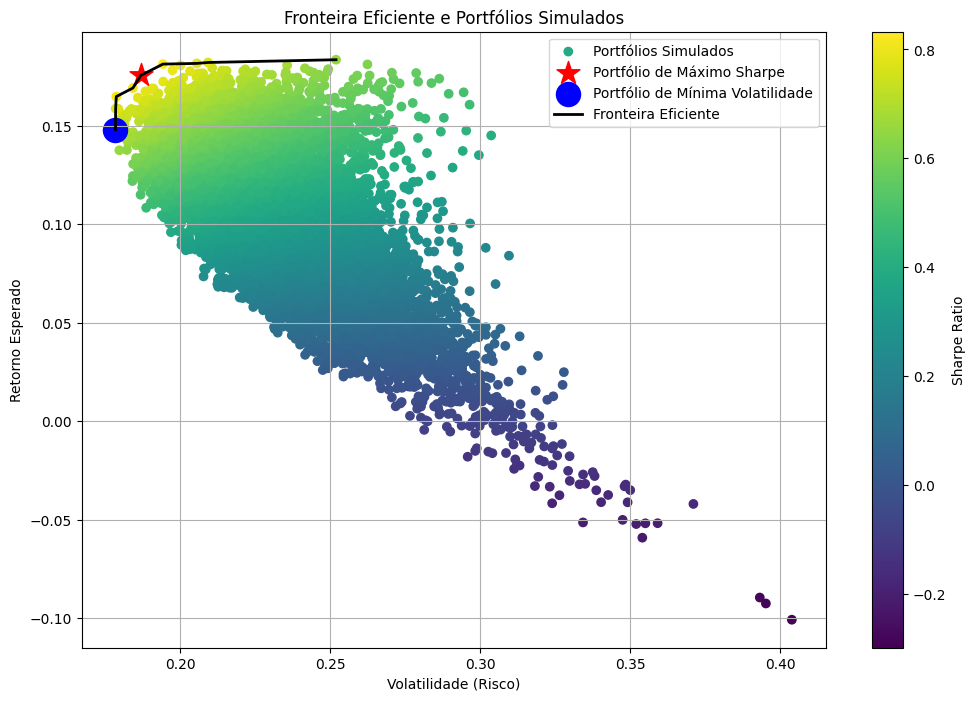

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(portfolios['Volatilidade'], portfolios['Retorno'], c=portfolios['Sharpe Ratio'], cmap='viridis', label='Portfólios Simulados')
plt.colorbar(label='Sharpe Ratio')

# Highlight max Sharpe ratio portfolio
plt.scatter(sharpe_portfolio_volatility, sharpe_portfolio_return, marker='*', color='red', s=300, label='Portfólio de Máximo Sharpe')

# Highlight minimum volatility portfolio
plt.scatter(min_vol_portfolio_volatility, min_vol_portfolio_return, marker='o', color='blue', s=300, label='Portfólio de Mínima Volatilidade')

# Calculate the Efficient Frontier
# Sort portfolios by volatility
portfolios_sorted_by_vol = portfolios.sort_values(by='Volatilidade')

efficient_frontier_points = []
max_return_for_volatility = -np.inf

for i, row in portfolios_sorted_by_vol.iterrows():
    if row['Retorno'] > max_return_for_volatility:
        efficient_frontier_points.append(row)
        max_return_for_volatility = row['Retorno']

efficient_frontier_df = pd.DataFrame(efficient_frontier_points)

# Plot the Efficient Frontier
plt.plot(efficient_frontier_df['Volatilidade'], efficient_frontier_df['Retorno'], color='black', linestyle='-', linewidth=2, label='Fronteira Eficiente')

plt.title('Fronteira Eficiente e Portfólios Simulados')
plt.xlabel('Volatilidade (Risco)')
plt.ylabel('Retorno Esperado')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
max_sharpe_portfolio = portfolios.iloc[max_sharpe_idx]
print("\n--- Portfólio de Máximo Sharpe Ratio ---")
print(f"Retorno Esperado: {max_sharpe_portfolio['Retorno']:.2%}")
print(f"Volatilidade (Risco): {max_sharpe_portfolio['Volatilidade']:.2%}")
print(f"Sharpe Ratio: {max_sharpe_portfolio['Sharpe Ratio']:.2f}")


--- Portfólio de Máximo Sharpe Ratio ---
Retorno Esperado: 17.56%
Volatilidade (Risco): 18.68%
Sharpe Ratio: 0.83


In [ ]:
max_sharpe_weights = all_weights[max_sharpe_idx]

print("\n--- Pesos do Portfólio de Máximo Sharpe Ratio ---")
for i, ticker in enumerate(tickers):
    print(f"{ticker}: {max_sharpe_weights[i]:.2%}")


--- Pesos do Portfólio de Máximo Sharpe Ratio ---
WEGE3.SA: 4.67%
ITUB4.SA: 65.82%
VALE3.SA: 0.91%
LREN3.SA: 9.60%
IVVB11.SA: 19.00%


In [ ]:
def calculate_shares_to_buy(weights, current_prices, total_investment):
    """
    Calculates the number of shares to buy for each asset.

    Args:
        weights (np.array): Array of portfolio weights for each asset.
        current_prices (pd.Series or np.array): Current price of each asset.
        total_investment (float): Total amount of money to invest.

    Returns:
        pd.Series: Number of shares to buy for each asset (integer values).
    """
    # Calculate the amount to invest in each asset
    investment_per_asset = weights * total_investment

    # Calculate the number of shares for each asset (using floor to avoid fractional shares)
    shares_to_buy = np.floor(investment_per_asset / current_prices)

    return pd.Series(shares_to_buy, index=tickers)

# Exemplo de uso:
# Obter os preços atuais (últimos preços disponíveis no DataFrame 'dados')
current_prices = dados.iloc[-1]

# Definir o valor total a ser investido
total_investment_amount = 10000.0  # Exemplo: R$ 10.000

# Calcular o número de ações a comprar
shares_for_max_sharpe = calculate_shares_to_buy(max_sharpe_weights, current_prices, total_investment_amount)

print(f"\n--- Número de Ações a Comprar para um Investimento de R$ {total_investment_amount:,.2f} ---")
print(shares_for_max_sharpe)


--- Número de Ações a Comprar para um Investimento de R$ 10,000.00 ---
WEGE3.SA     36.0
ITUB4.SA     10.0
VALE3.SA     11.0
LREN3.SA      6.0
IVVB11.SA    16.0
Name: 2026-01-30 00:00:00, dtype: float64


# Previsão LSTM

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
import warnings
warnings.filterwarnings('ignore')

# Configurações do modelo
window_size = 60
lstm_annual_returns = []
lstm_predictions_dict = {}

print("Treinando modelos LSTM para os ativos...")
for ticker in tickers:
    print(f"Treinando LSTM para {ticker}...")
    # Pegar o histórico de fechamento do ativo
    serie = dados[ticker].dropna().values.reshape(-1, 1)

    # Normalização
    scaler = MinMaxScaler(feature_range=(0, 1))
    serie_scaled = scaler.fit_transform(serie)

    # Janelamento dos dados
    X_train, y_train = [], []
    for i in range(window_size, len(serie_scaled)):
        X_train.append(serie_scaled[i-window_size:i, 0])
        y_train.append(serie_scaled[i, 0])

    X_train, y_train = np.array(X_train), np.array(y_train)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

    # Construção do modelo LSTM
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Treinamento (usamos poucas epochs para a demonstração ser rápida; ajuste caso precise de mais precisão)
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

    # Previsão do preço do próximo dia
    last_window = serie_scaled[-window_size:]
    last_window = np.reshape(last_window, (1, window_size, 1))
    pred_scaled = model.predict(last_window, verbose=0)
    pred_price = scaler.inverse_transform(pred_scaled)[0][0]

    current_price = serie[-1][0]

    # Derivando o retorno esperado diário (logarítmico) e anualizando-o
    expected_daily_return = np.log(pred_price / current_price)
    expected_annual_return = expected_daily_return * 252

    lstm_predictions_dict[ticker] = expected_annual_return
    lstm_annual_returns.append(expected_annual_return)

lstm_annual_returns = np.array(lstm_annual_returns)

print("\n--- Retornos Anualizados Esperados (Previsão LSTM) ---")
for t, r in lstm_predictions_dict.items():
    print(f"{t}: {r:.2%}")

Treinando modelos LSTM para os ativos...
Treinando LSTM para WEGE3.SA...


Treinando LSTM para ITUB4.SA...
Treinando LSTM para VALE3.SA...
Treinando LSTM para LREN3.SA...
Treinando LSTM para IVVB11.SA...

--- Retornos Anualizados Esperados (Previsão LSTM) ---
WEGE3.SA: -145.41%
ITUB4.SA: -247.28%
VALE3.SA: 493.34%
LREN3.SA: 632.06%
IVVB11.SA: -533.93%


# Monte Carlo com previsões

In [ ]:
ret_arr_lstm = np.zeros(num_portfolios)
vol_arr_lstm = np.zeros(num_portfolios)
sharpe_arr_lstm = np.zeros(num_portfolios)
all_weights_lstm = np.zeros((num_portfolios, len(tickers)))

# A matriz de covariância histórica continua sendo a base do risco
cov_matrix = retornos_log.cov() * 252

for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    all_weights_lstm[i, :] = weights

    # A MUDANÇA ESTÁ AQUI: Multiplicamos os pesos pelos retornos previstos pelo LSTM!
    expected_return = np.sum(weights * lstm_annual_returns)
    expected_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    ret_arr_lstm[i] = expected_return
    vol_arr_lstm[i] = expected_volatility
    sharpe_arr_lstm[i] = expected_return / expected_volatility

# Obtendo o portfólio de maior Índice de Sharpe (Abordagem LSTM)
max_sharpe_idx_lstm = np.argmax(sharpe_arr_lstm)
max_sharpe_weights_lstm = all_weights_lstm[max_sharpe_idx_lstm]

print("--- Portfólio de Maior Sharpe (Abordagem LSTM) ---")
print(f"Retorno Esperado: {ret_arr_lstm[max_sharpe_idx_lstm]:.2%}")
print(f"Volatilidade Esperada: {vol_arr_lstm[max_sharpe_idx_lstm]:.2%}")
print(f"Sharpe Ratio: {sharpe_arr_lstm[max_sharpe_idx_lstm]:.4f}")
print("Pesos:")
for t, w in zip(tickers, max_sharpe_weights_lstm):
    print(f"{t}: {w:.2%}")

--- Portfólio de Maior Sharpe (Abordagem LSTM) ---
Retorno Esperado: 565.22%
Volatilidade Esperada: 30.69%
Sharpe Ratio: 18.4175
Pesos:
WEGE3.SA: 0.65%
ITUB4.SA: 0.15%
VALE3.SA: 29.29%
LREN3.SA: 68.21%
IVVB11.SA: 1.70%


# Comparação métodos

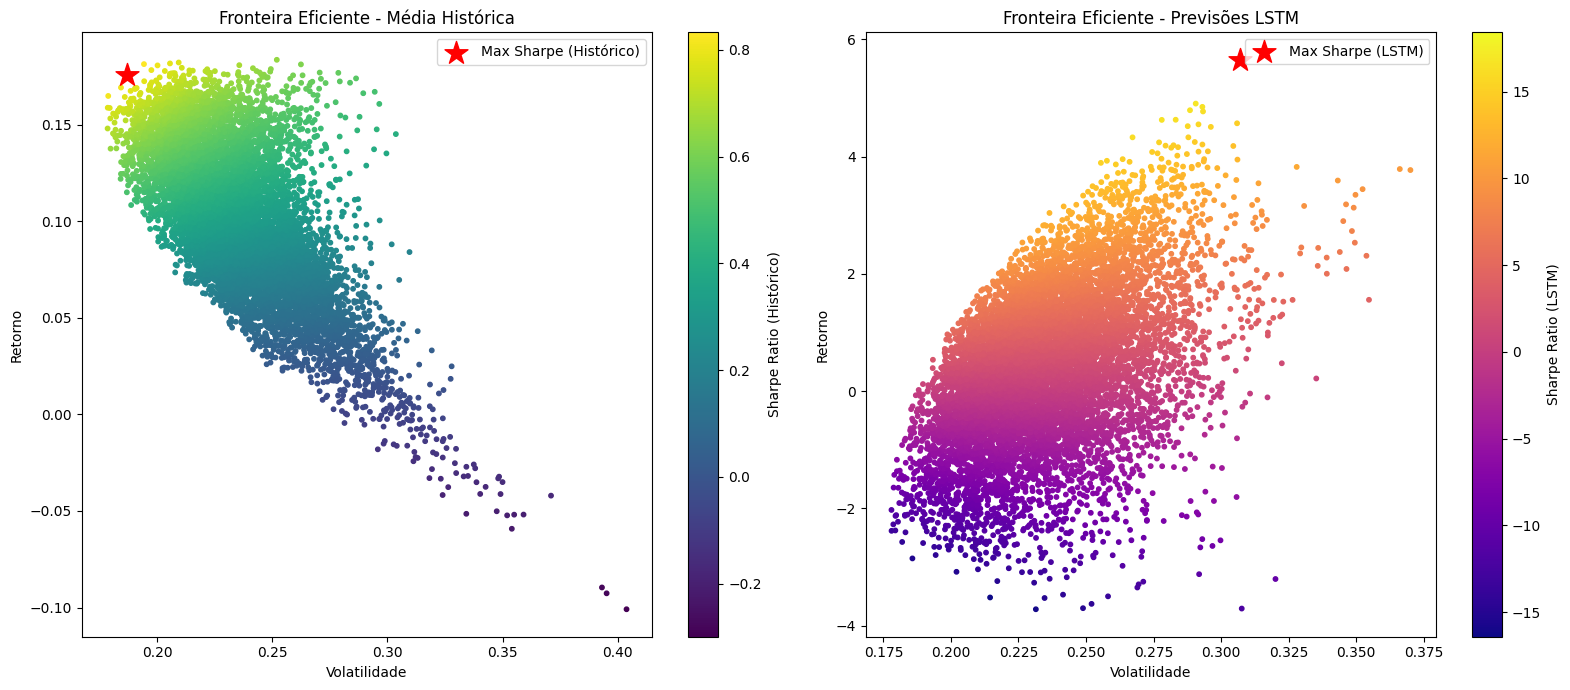

In [ ]:
plt.figure(figsize=(16, 7))

# Plot Fronteira Histórica (Baseada nos dados anteriores do seu notebook)
plt.subplot(1, 2, 1)
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', s=10)
plt.colorbar(label='Sharpe Ratio (Histórico)')
plt.scatter(vol_arr[max_sharpe_idx], ret_arr[max_sharpe_idx], color='red', marker='*', s=300, label='Max Sharpe (Histórico)')
plt.title('Fronteira Eficiente - Média Histórica')
plt.xlabel('Volatilidade')
plt.ylabel('Retorno')
plt.legend()

# Plot Fronteira baseada no LSTM
plt.subplot(1, 2, 2)
plt.scatter(vol_arr_lstm, ret_arr_lstm, c=sharpe_arr_lstm, cmap='plasma', s=10)
plt.colorbar(label='Sharpe Ratio (LSTM)')
plt.scatter(vol_arr_lstm[max_sharpe_idx_lstm], ret_arr_lstm[max_sharpe_idx_lstm], color='red', marker='*', s=300, label='Max Sharpe (LSTM)')
plt.title('Fronteira Eficiente - Previsões LSTM')
plt.xlabel('Volatilidade')
plt.ylabel('Retorno')
plt.legend()

plt.tight_layout()
plt.show()

[*********************100%***********************]  5 of 5 completed


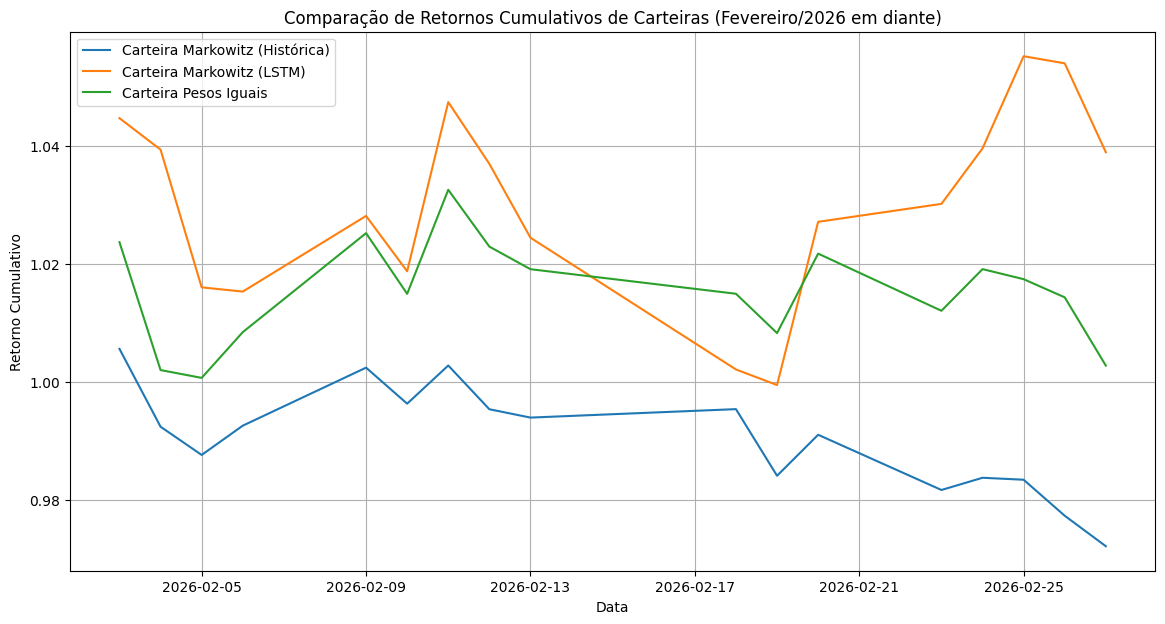


--- Retornos Finais (a partir de 01/Fev/2026) ---
Markowitz Histórica: -2.79%
Markowitz LSTM: 3.89%
Pesos Iguais: 0.27%


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# --- 1. Definir os pesos das carteiras ---

# Carteira Markowitz (Média Histórica) - pesos já calculados em max_sharpe_weights
weights_historical_markowitz = max_sharpe_weights

# Carteira Markowitz (LSTM) - pesos já calculados em max_sharpe_weights_lstm
weights_lstm_markowitz = max_sharpe_weights_lstm

# Carteira com pesos iguais
weights_equal = np.array([1/len(tickers)] * len(tickers))

# --- 2. Baixar dados para o período de comparação (Fevereiro de 2026 em diante) ---
# Usaremos a data atual como fim para incluir os dados mais recentes se disponíveis
comparison_data = yf.download(tickers, start="2026-02-01", end="2026-02-28")['Close']

# Cálculo dos Retornos Logarítmicos para o período de comparação
comparison_returns_log = np.log(comparison_data / comparison_data.shift(1)).dropna()

# --- 3. Calcular Retornos Cumulativos para cada carteira ---

# Função auxiliar para calcular retornos cumulativos
def calculate_cumulative_returns(returns_df, weights):
    portfolio_daily_returns = (returns_df * weights).sum(axis=1)
    return np.exp(portfolio_daily_returns.cumsum())

cum_returns_historical = calculate_cumulative_returns(comparison_returns_log, weights_historical_markowitz)
cum_returns_lstm = calculate_cumulative_returns(comparison_returns_log, weights_lstm_markowitz)
cum_returns_equal = calculate_cumulative_returns(comparison_returns_log, weights_equal)

# --- 4. Comparar e Visualizar os Retornos ---

plt.figure(figsize=(14, 7))
plt.plot(cum_returns_historical, label='Carteira Markowitz (Histórica)')
plt.plot(cum_returns_lstm, label='Carteira Markowitz (LSTM)')
plt.plot(cum_returns_equal, label='Carteira Pesos Iguais')

plt.title('Comparação de Retornos Cumulativos de Carteiras (Fevereiro/2026)')
plt.xlabel('Data')
plt.ylabel('Retorno Cumulativo')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Retornos Finais (a partir de 01/Fev/2026) ---")
if not cum_returns_historical.empty:
    print(f"Markowitz Histórica: {cum_returns_historical.iloc[-1]-1:.2%}")
if not cum_returns_lstm.empty:
    print(f"Markowitz LSTM: {cum_returns_lstm.iloc[-1]-1:.2%}")
if not cum_returns_equal.empty:
    print(f"Pesos Iguais: {cum_returns_equal.iloc[-1]-1:.2%}")
